In [9]:
import pandas as pd
from pathlib import Path

For each isoform caller, I am generating:
1. Table of isoform counts identified for each sample
2. Test stat, z-score, and rankings for each sample-gene pair specified in the Sample_gene_pairs_iso_allelic.csv
3. Number of MFN2 isoforms identified as an example

In [10]:
# Function to split samples
def split_samples(df):
    records = []

    for _, row in df.iterrows():
        base_sample = row["Sample"]

        # Cyclo sample
        records.append({
            "Sample": f"{base_sample}_cyclo",
            "Isoform": row.name if "Isoform" in df.index.names else None,
            "reads": row["cyclo_count"]
        })

        # Noncyclo sample
        records.append({
            "Sample": f"{base_sample}_noncyclo",
            "Isoform": row.name if "Isoform" in df.index.names else None,
            "reads": row["noncyclo_count"]
        })

    return pd.DataFrame(records)

# IsoSeq

In [3]:
# Load your long_format_annotated.tsv.gz from the Intermediate folder of the IsoRanker output
df = pd.read_csv("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/long_format_annotated.tsv.gz", sep="\t", index_col = 0, compression="infer")

split_df = split_samples(df)

# Count isoforms with at least one read per (Sample)
isoform_counts = (
    split_df
    .query("reads > 0")
    .groupby("Sample")["Isoform"]
    .nunique()
    .reset_index(name="num_isoforms_with_reads")
)

print(isoform_counts)

isoform_counts.to_csv("isoform_counts_IsoSeq.tsv", sep="\t", index=False)

                  Sample  num_isoforms_with_reads
0      BCH_0252-01_cyclo                   423769
1   BCH_0252-01_noncyclo                   338246
2      BCH_1199-01_cyclo                   497214
3   BCH_1199-01_noncyclo                   357397
4      BCH_1877-01_cyclo                   346531
..                   ...                      ...
57    UDN860070_noncyclo                   345095
58       UDN924176_cyclo                   487834
59    UDN924176_noncyclo                   346656
60       UDN966087_cyclo                   348879
61    UDN966087_noncyclo                   253713

[62 rows x 2 columns]


In [20]:
###########################
# Inputs
###########################
TABLE1_PATH = "File_names_iso_allelic.csv"            # CSV: columns -> Name, Test stat and z-score, Rankings (filenames only)
TABLE2_PATH = "Sample_gene_pairs_iso_allelic.csv"     # CSV: columns -> Sample, Gene, effect columns, Noncyclo expression, Cyclo expression
OUTPUT_PATH = "Sample_gene_pairs_populated_iso_allelic_IsoSeq.csv"
MISSING_VALUE = ""                        # or set to "NA"
ADD_ISOFORM_ID_COLS = True                # also add '<effect> (isoform used)' columns

# Base directories for files referenced by Table 1
TS_DIR = Path("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate")
RK_DIR = Path("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate")

# Lookup table for expressions
LOOKUP_DIR = Path("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/browser/lookup_tables")
LOOKUP_FILE = "sample_gene_rankings_lookup_table.tsv.gz"

###########################
# Effect columns expected in Table 2
###########################

GENE_EFFECTS = [
    "Gene NMD",
    "Gene Noncyclo LOE",
    "Gene Noncyclo GOE",
    "Gene Cyclo GOE",
    "Gene NMD rare steady state",
    "Gene Noncyclo allelic imbalance"
]
ISOFORM_EFFECTS = [
    "Isoform NMD",
    "Isoform Noncyclo LOE",
    "Isoform Noncyclo GOE",
    "Isoform Cyclo GOE",
    "Isoform Noncyclo allelic imbalance",
    "Isoform Cyclo allelic imbalance"
]
ALL_EFFECTS = GENE_EFFECTS + ISOFORM_EFFECTS

###########################
# Exact column names in the files
###########################

FILE_SAMPLE_COL     = "Sample"
FILE_STAT_GENE_COL  = "associated_gene"            # test-stat TSVs
FILE_RANK_GENE_COL  = "original_associated_gene"   # ranking TSVs. Use "associated_gene" instead if running jupyternotebook without handling fusions.
FILE_ISO_COL        = "Isoform"
STAT_TS_COL         = "test_statistic"
STAT_Z_COL          = "z_score_of_test_stat"
RANK_COL            = "rank_top_99_5_percentile"

# Expression lookup exact columns
LOOKUP_NONC_COL = "Noncyclo_TPM"
LOOKUP_CYCL_COL = "Cyclo_TPM"

###########################
# Exact column names in Table 2
###########################
T2_SAMPLE_COL = "Sample"
T2_GENE_COL   = "Gene"
T2_NONC_EXPR  = "Noncyclo expression"
T2_CYCL_EXPR  = "Cyclo expression"

###########################
# Load inputs 
###########################
table1 = pd.read_csv(TABLE1_PATH, dtype="string")
table2 = pd.read_csv(TABLE2_PATH, dtype="string")

req_t1 = ["Name", "Test stat and z-score", "Rankings"] # required columns
missing_t1 = [c for c in req_t1 if c not in table1.columns]
if missing_t1:
    raise KeyError(f"Table 1 is missing required columns: {missing_t1}. Found: {list(table1.columns)}")

req_t2 = [T2_SAMPLE_COL, T2_GENE_COL, T2_NONC_EXPR, T2_CYCL_EXPR] + ALL_EFFECTS
missing_t2 = [c for c in req_t2 if c not in table2.columns]
if missing_t2:
    raise KeyError(f"Table 2 is missing required columns: {missing_t2}. Found: {list(table2.columns)}")

###########################
#  Build effect -> (test_stat_path, ranking_path) mapping from Table 1 (join with base dirs)
###########################
effect_to_files = {}
for _, r in table1.iterrows():
    eff = str(r["Name"])
    ts_filename = str(r["Test stat and z-score"]).strip()
    rk_filename = str(r["Rankings"]).strip()
    ts_path = TS_DIR / ts_filename
    rk_path = RK_DIR / rk_filename
    effect_to_files[eff] = (ts_path, rk_path)

missing_effects = [e for e in ALL_EFFECTS if e not in effect_to_files]
if missing_effects:
    raise KeyError(f"Table 1 is missing rows for these effects: {missing_effects}")

def read_tsv_with_exact_cols(path: Path, needed):
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    # Header check
    header = pd.read_csv(path, sep="\t", nrows=0, compression="infer").columns.tolist()
    missing = [c for c in needed if c not in header]
    if missing:
        raise KeyError(f"{path.name} missing required columns: {missing}. Found: {header}")
    # Read gzip-aware
    return pd.read_csv(path, sep="\t", usecols=needed, dtype="string", compression="infer")

def pack_vals(ts, zs, rk):
    if pd.isna(ts) or pd.isna(zs) or pd.isna(rk):
        return MISSING_VALUE
    return f"{ts};{zs};{rk}"

###########################
#  Effects: gene-level (many-to-many OK, will pick best by rank then raw z) 
###########################
def build_gene_lookup(ts_path: Path, rk_path: Path):
    stat_needed = [FILE_SAMPLE_COL, FILE_STAT_GENE_COL, STAT_TS_COL, STAT_Z_COL]
    rank_needed = [FILE_SAMPLE_COL, FILE_RANK_GENE_COL, RANK_COL]
    df_stat = read_tsv_with_exact_cols(ts_path, stat_needed)
    df_rank = read_tsv_with_exact_cols(rk_path, rank_needed)

    merged = pd.merge(
        df_stat, df_rank,
        left_on=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL],
        right_on=[FILE_SAMPLE_COL, FILE_RANK_GENE_COL],
        how="inner"
    )

    merged["_rank_num"] = pd.to_numeric(merged[RANK_COL], errors="coerce")
    merged["_z_num"]    = pd.to_numeric(merged[STAT_Z_COL], errors="coerce")  # raw z, not abs
    merged = merged.dropna(subset=["_rank_num"])

    merged = merged.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, "_rank_num", "_z_num"],
        ascending=[True, True, True, False]  # smallest rank, then highest z
    )
    grp = merged.groupby([FILE_SAMPLE_COL, FILE_STAT_GENE_COL], as_index=False).first()

    return {
        (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): pack_vals(row[STAT_TS_COL], row[STAT_Z_COL], row[RANK_COL])
        for _, row in grp.iterrows()
    }

###########################
#  Effects: isoform-level (collapse dups, will pick best by rank then raw z)
###########################
def build_isoform_best_lookup(ts_path: Path, rk_path: Path):
    stat_needed = [FILE_SAMPLE_COL, FILE_STAT_GENE_COL, FILE_ISO_COL, STAT_TS_COL, STAT_Z_COL]
    rank_needed = [FILE_SAMPLE_COL, FILE_RANK_GENE_COL, FILE_ISO_COL, RANK_COL]
    df_stat = read_tsv_with_exact_cols(ts_path, stat_needed)
    df_rank = read_tsv_with_exact_cols(rk_path, rank_needed)

    merged = pd.merge(
        df_stat, df_rank,
        left_on=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, FILE_ISO_COL],
        right_on=[FILE_SAMPLE_COL, FILE_RANK_GENE_COL, FILE_ISO_COL],
        how="inner"
    )

    merged["_rank_num"] = pd.to_numeric(merged[RANK_COL], errors="coerce")
    merged["_z_num"]    = pd.to_numeric(merged[STAT_Z_COL], errors="coerce")  # raw z, not abs
    merged = merged.dropna(subset=["_rank_num"])

    # 1) Collapse duplicates within the same isoform key: best rank, then highest raw z
    merged = merged.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, FILE_ISO_COL, "_rank_num", "_z_num"],
        ascending=[True, True, True, True, False]
    ).drop_duplicates(subset=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, FILE_ISO_COL], keep="first")

    # 2) Pick best isoform per (Sample, Gene): best rank, then highest raw z, then Isoform for determinism
    merged = merged.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, "_rank_num", "_z_num", FILE_ISO_COL],
        ascending=[True, True, True, False, True]
    )
    grp = merged.groupby([FILE_SAMPLE_COL, FILE_STAT_GENE_COL], as_index=False).first()

    best_lookup = {
        (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): pack_vals(row[STAT_TS_COL], row[STAT_Z_COL], row[RANK_COL])
        for _, row in grp.iterrows()
    }
    iso_used = {
        (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): row[FILE_ISO_COL]
        for _, row in grp.iterrows()
    }
    return best_lookup, iso_used

###########################
# Noncyclo_TPM and Cyclo_TPM from lookup table
###########################
def build_expression_maps(lookup_path: Path):
    needed = [FILE_SAMPLE_COL, FILE_STAT_GENE_COL, LOOKUP_NONC_COL, LOOKUP_CYCL_COL]  # lookup uses 'associated_gene'
    df = read_tsv_with_exact_cols(lookup_path, needed)

    df["_nonc_num"] = pd.to_numeric(df[LOOKUP_NONC_COL], errors="coerce")
    df["_cycl_num"] = pd.to_numeric(df[LOOKUP_CYCL_COL], errors="coerce")

    df = df.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, "_nonc_num", "_cycl_num"],
        ascending=[True, True, False, False]
    ).drop_duplicates(subset=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL], keep="first")

    nonc_map = { (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): row[LOOKUP_NONC_COL] for _, row in df.iterrows() }
    cycl_map = { (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): row[LOOKUP_CYCL_COL] for _, row in df.iterrows() }
    return nonc_map, cycl_map

###########################
# Lookup dictionaries
###########################
gene_lookups = {} # A dictionary of dictionaries. Each effect gets its own dictionary. Allows for: gene_lookups["Gene NMD"][("S1", "TP53")] == "1.8;2.5;15"
for eff in GENE_EFFECTS:
    ts_fp, rk_fp = effect_to_files[eff]
    gene_lookups[eff] = build_gene_lookup(ts_fp, rk_fp)

iso_lookups = {}
iso_used_maps = {}
for eff in ISOFORM_EFFECTS:
    ts_fp, rk_fp = effect_to_files[eff]
    best_lookup, iso_used = build_isoform_best_lookup(ts_fp, rk_fp)
    iso_lookups[eff] = best_lookup
    iso_used_maps[eff] = iso_used

# Expressions
lookup_path = LOOKUP_DIR / LOOKUP_FILE
nonc_map, cycl_map = build_expression_maps(lookup_path)

###########################
#  Fill Table 2 
###########################
keys_t2 = list(zip(table2[T2_SAMPLE_COL], table2[T2_GENE_COL]))

# Gene effects
for eff in GENE_EFFECTS:
    table2[eff] = [gene_lookups[eff].get((s, g), MISSING_VALUE) for s, g in keys_t2] #Get specific sample-gene (s, g) pair

# Isoform effects
for eff in ISOFORM_EFFECTS:
    table2[eff] = [iso_lookups[eff].get((s, g), MISSING_VALUE) for s, g in keys_t2]
    if ADD_ISOFORM_ID_COLS:
        colname = f"{eff} (isoform used)"
        table2[colname] = [iso_used_maps[eff].get((s, g), MISSING_VALUE) for s, g in keys_t2]

# Expressions
table2[T2_NONC_EXPR] = [nonc_map.get((s, g), MISSING_VALUE) for s, g in keys_t2]
table2[T2_CYCL_EXPR] = [cycl_map.get((s, g), MISSING_VALUE) for s, g in keys_t2]

# Save CSV
table2.to_csv(OUTPUT_PATH, index=False)
print(f"Done. Wrote: {OUTPUT_PATH}")


Done. Wrote: Sample_gene_pairs_populated_iso_allelic_IsoSeq.csv


In [24]:
df = pd.read_csv("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/long_format_annotated.tsv.gz", sep="\t", index_col = 0, compression="infer")
count_unique_isoforms = (
    df.query('associated_gene == "MFN2" and Sample == "UDN633333"') #The UDN633333 is actually not helpful here because even isoforms with zero reads in this sample will be counted
      .index.nunique()
)

print(count_unique_isoforms)


851


# IsoQuant

In [4]:
# Load your long_format_annotated.tsv.gz from the Intermediate folder of the IsoRanker output
df = pd.read_csv("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/IsoQuant/6.27.25/long_format_annotated.tsv.gz", sep="\t", index_col = 0, compression="infer")

split_df = split_samples(df)

# Count isoforms with at least one read per (Sample)
isoform_counts = (
    split_df
    .query("reads > 0")
    .groupby("Sample")["Isoform"]
    .nunique()
    .reset_index(name="num_isoforms_with_reads")
)

print(isoform_counts)

isoform_counts.to_csv("isoform_counts_IsoQuant.tsv", sep="\t", index=False)


                  Sample  num_isoforms_with_reads
0      BCH_0252-01_cyclo                    52640
1   BCH_0252-01_noncyclo                    48330
2      BCH_1199-01_cyclo                    52279
3   BCH_1199-01_noncyclo                    48131
4      BCH_1877-01_cyclo                    46508
..                   ...                      ...
57    UDN860070_noncyclo                    51238
58       UDN924176_cyclo                    57708
59    UDN924176_noncyclo                    50005
60       UDN966087_cyclo                    47577
61    UDN966087_noncyclo                    47915

[62 rows x 2 columns]


In [ ]:
df = pd.read_csv("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/IsoQuant/6.27.25/long_format_annotated.tsv.gz", sep="\t", index_col = 0, compression="infer")
count_unique_isoforms = (
    df.query('associated_gene == "MFN2" and Sample == "UDN633333"')
      .index.nunique()
)

print(count_unique_isoforms)


In [29]:
###########################
# Inputs
###########################
TABLE1_PATH = "File_names_iso_allelic.csv"            # CSV: columns -> Name, Test stat and z-score, Rankings (filenames only)
TABLE2_PATH = "Sample_gene_pairs_iso_allelic.csv"     # CSV: columns -> Sample, Gene, effect columns, Noncyclo expression, Cyclo expression
OUTPUT_PATH = "Sample_gene_pairs_populated_iso_allelic_IsoQuant.csv"
MISSING_VALUE = ""                        # or set to "NA"
ADD_ISOFORM_ID_COLS = True                # also add '<effect> (isoform used)' columns

# Base directories for files referenced by Table 1
TS_DIR = Path("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/IsoQuant/10.12.25/Output/intermediate")
RK_DIR = Path("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/IsoQuant/10.12.25/Output/intermediate")

# Lookup table for expressions
LOOKUP_DIR = Path("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/IsoQuant/10.12.25/Output/browser/lookup_tables")
LOOKUP_FILE = "sample_gene_rankings_lookup_table.tsv.gz"

###########################
# Effect columns expected in Table 2
###########################

GENE_EFFECTS = [
    "Gene NMD",
    "Gene Noncyclo LOE",
    "Gene Noncyclo GOE",
    "Gene Cyclo GOE",
    "Gene NMD rare steady state",
    "Gene Noncyclo allelic imbalance"
]
ISOFORM_EFFECTS = [
    "Isoform NMD",
    "Isoform Noncyclo LOE",
    "Isoform Noncyclo GOE",
    "Isoform Cyclo GOE",
    "Isoform Noncyclo allelic imbalance",
    "Isoform Cyclo allelic imbalance"
]
ALL_EFFECTS = GENE_EFFECTS + ISOFORM_EFFECTS

###########################
# Exact column names in the files
###########################

FILE_SAMPLE_COL     = "Sample"
FILE_STAT_GENE_COL  = "associated_gene"            # test-stat TSVs
FILE_RANK_GENE_COL  = "original_associated_gene"   # ranking TSVs. Use "associated_gene" instead if running jupyternotebook without handling fusions.
FILE_ISO_COL        = "Isoform"
STAT_TS_COL         = "test_statistic"
STAT_Z_COL          = "z_score_of_test_stat"
RANK_COL            = "rank_top_99_5_percentile"

# Expression lookup exact columns
LOOKUP_NONC_COL = "Noncyclo_TPM"
LOOKUP_CYCL_COL = "Cyclo_TPM"

###########################
# Exact column names in Table 2
###########################
T2_SAMPLE_COL = "Sample"
T2_GENE_COL   = "Gene"
T2_NONC_EXPR  = "Noncyclo expression"
T2_CYCL_EXPR  = "Cyclo expression"

###########################
# Load inputs 
###########################
table1 = pd.read_csv(TABLE1_PATH, dtype="string")
table2 = pd.read_csv(TABLE2_PATH, dtype="string")

req_t1 = ["Name", "Test stat and z-score", "Rankings"] # required columns
missing_t1 = [c for c in req_t1 if c not in table1.columns]
if missing_t1:
    raise KeyError(f"Table 1 is missing required columns: {missing_t1}. Found: {list(table1.columns)}")

req_t2 = [T2_SAMPLE_COL, T2_GENE_COL, T2_NONC_EXPR, T2_CYCL_EXPR] + ALL_EFFECTS
missing_t2 = [c for c in req_t2 if c not in table2.columns]
if missing_t2:
    raise KeyError(f"Table 2 is missing required columns: {missing_t2}. Found: {list(table2.columns)}")

###########################
#  Build effect -> (test_stat_path, ranking_path) mapping from Table 1 (join with base dirs)
###########################
effect_to_files = {}
for _, r in table1.iterrows():
    eff = str(r["Name"])
    ts_filename = str(r["Test stat and z-score"]).strip()
    rk_filename = str(r["Rankings"]).strip()
    ts_path = TS_DIR / ts_filename
    rk_path = RK_DIR / rk_filename
    effect_to_files[eff] = (ts_path, rk_path)

missing_effects = [e for e in ALL_EFFECTS if e not in effect_to_files]
if missing_effects:
    raise KeyError(f"Table 1 is missing rows for these effects: {missing_effects}")

def read_tsv_with_exact_cols(path: Path, needed):
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    # Header check
    header = pd.read_csv(path, sep="\t", nrows=0, compression="infer").columns.tolist()
    missing = [c for c in needed if c not in header]
    if missing:
        raise KeyError(f"{path.name} missing required columns: {missing}. Found: {header}")
    # Read gzip-aware
    return pd.read_csv(path, sep="\t", usecols=needed, dtype="string", compression="infer")

def pack_vals(ts, zs, rk):
    if pd.isna(ts) or pd.isna(zs) or pd.isna(rk):
        return MISSING_VALUE
    return f"{ts};{zs};{rk}"

###########################
#  Effects: gene-level (many-to-many OK, will pick best by rank then raw z) 
###########################
def build_gene_lookup(ts_path: Path, rk_path: Path):
    stat_needed = [FILE_SAMPLE_COL, FILE_STAT_GENE_COL, STAT_TS_COL, STAT_Z_COL]
    rank_needed = [FILE_SAMPLE_COL, FILE_RANK_GENE_COL, RANK_COL]
    df_stat = read_tsv_with_exact_cols(ts_path, stat_needed)
    df_rank = read_tsv_with_exact_cols(rk_path, rank_needed)

    merged = pd.merge(
        df_stat, df_rank,
        left_on=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL],
        right_on=[FILE_SAMPLE_COL, FILE_RANK_GENE_COL],
        how="inner"
    )

    merged["_rank_num"] = pd.to_numeric(merged[RANK_COL], errors="coerce")
    merged["_z_num"]    = pd.to_numeric(merged[STAT_Z_COL], errors="coerce")  # raw z, not abs
    merged = merged.dropna(subset=["_rank_num"])

    merged = merged.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, "_rank_num", "_z_num"],
        ascending=[True, True, True, False]  # smallest rank, then highest z
    )
    grp = merged.groupby([FILE_SAMPLE_COL, FILE_STAT_GENE_COL], as_index=False).first()

    return {
        (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): pack_vals(row[STAT_TS_COL], row[STAT_Z_COL], row[RANK_COL])
        for _, row in grp.iterrows()
    }

###########################
#  Effects: isoform-level (collapse dups, will pick best by rank then raw z)
###########################
def build_isoform_best_lookup(ts_path: Path, rk_path: Path):
    stat_needed = [FILE_SAMPLE_COL, FILE_STAT_GENE_COL, FILE_ISO_COL, STAT_TS_COL, STAT_Z_COL]
    rank_needed = [FILE_SAMPLE_COL, FILE_RANK_GENE_COL, FILE_ISO_COL, RANK_COL]
    df_stat = read_tsv_with_exact_cols(ts_path, stat_needed)
    df_rank = read_tsv_with_exact_cols(rk_path, rank_needed)

    merged = pd.merge(
        df_stat, df_rank,
        left_on=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, FILE_ISO_COL],
        right_on=[FILE_SAMPLE_COL, FILE_RANK_GENE_COL, FILE_ISO_COL],
        how="inner"
    )

    merged["_rank_num"] = pd.to_numeric(merged[RANK_COL], errors="coerce")
    merged["_z_num"]    = pd.to_numeric(merged[STAT_Z_COL], errors="coerce")  # raw z, not abs
    merged = merged.dropna(subset=["_rank_num"])

    # 1) Collapse duplicates within the same isoform key: best rank, then highest raw z
    merged = merged.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, FILE_ISO_COL, "_rank_num", "_z_num"],
        ascending=[True, True, True, True, False]
    ).drop_duplicates(subset=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, FILE_ISO_COL], keep="first")

    # 2) Pick best isoform per (Sample, Gene): best rank, then highest raw z, then Isoform for determinism
    merged = merged.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, "_rank_num", "_z_num", FILE_ISO_COL],
        ascending=[True, True, True, False, True]
    )
    grp = merged.groupby([FILE_SAMPLE_COL, FILE_STAT_GENE_COL], as_index=False).first()

    best_lookup = {
        (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): pack_vals(row[STAT_TS_COL], row[STAT_Z_COL], row[RANK_COL])
        for _, row in grp.iterrows()
    }
    iso_used = {
        (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): row[FILE_ISO_COL]
        for _, row in grp.iterrows()
    }
    return best_lookup, iso_used

###########################
# Noncyclo_TPM and Cyclo_TPM from lookup table
###########################
def build_expression_maps(lookup_path: Path):
    needed = [FILE_SAMPLE_COL, FILE_STAT_GENE_COL, LOOKUP_NONC_COL, LOOKUP_CYCL_COL]  # lookup uses 'associated_gene'
    df = read_tsv_with_exact_cols(lookup_path, needed)

    df["_nonc_num"] = pd.to_numeric(df[LOOKUP_NONC_COL], errors="coerce")
    df["_cycl_num"] = pd.to_numeric(df[LOOKUP_CYCL_COL], errors="coerce")

    df = df.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, "_nonc_num", "_cycl_num"],
        ascending=[True, True, False, False]
    ).drop_duplicates(subset=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL], keep="first")

    nonc_map = { (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): row[LOOKUP_NONC_COL] for _, row in df.iterrows() }
    cycl_map = { (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): row[LOOKUP_CYCL_COL] for _, row in df.iterrows() }
    return nonc_map, cycl_map

###########################
# Lookup dictionaries
###########################
gene_lookups = {} # A dictionary of dictionaries. Each effect gets its own dictionary. Allows for: gene_lookups["Gene NMD"][("S1", "TP53")] == "1.8;2.5;15"
for eff in GENE_EFFECTS:
    ts_fp, rk_fp = effect_to_files[eff]
    gene_lookups[eff] = build_gene_lookup(ts_fp, rk_fp)

iso_lookups = {}
iso_used_maps = {}
for eff in ISOFORM_EFFECTS:
    ts_fp, rk_fp = effect_to_files[eff]
    best_lookup, iso_used = build_isoform_best_lookup(ts_fp, rk_fp)
    iso_lookups[eff] = best_lookup
    iso_used_maps[eff] = iso_used

# Expressions
lookup_path = LOOKUP_DIR / LOOKUP_FILE
nonc_map, cycl_map = build_expression_maps(lookup_path)

###########################
#  Fill Table 2 
###########################
keys_t2 = list(zip(table2[T2_SAMPLE_COL], table2[T2_GENE_COL]))

# Gene effects
for eff in GENE_EFFECTS:
    table2[eff] = [gene_lookups[eff].get((s, g), MISSING_VALUE) for s, g in keys_t2] #Get specific sample-gene (s, g) pair

# Isoform effects
for eff in ISOFORM_EFFECTS:
    table2[eff] = [iso_lookups[eff].get((s, g), MISSING_VALUE) for s, g in keys_t2]
    if ADD_ISOFORM_ID_COLS:
        colname = f"{eff} (isoform used)"
        table2[colname] = [iso_used_maps[eff].get((s, g), MISSING_VALUE) for s, g in keys_t2]

# Expressions
table2[T2_NONC_EXPR] = [nonc_map.get((s, g), MISSING_VALUE) for s, g in keys_t2]
table2[T2_CYCL_EXPR] = [cycl_map.get((s, g), MISSING_VALUE) for s, g in keys_t2]

# Save CSV
table2.to_csv(OUTPUT_PATH, index=False)
print(f"Done. Wrote: {OUTPUT_PATH}")


Done. Wrote: Sample_gene_pairs_populated_iso_allelic_IsoQuant.csv


In [31]:
# Just populate test stat and z-score. No rankings.

###########################
#  Inputs
###########################
TABLE1_PATH = "File_names_iso_allelic.csv"
TABLE2_PATH = "Sample_gene_pairs_iso_allelic.csv"
OUTPUT_PATH = "Sample_gene_pairs_populated_iso_allelic_IsoQuant_no_rankings.csv"
MISSING_VALUE = ""
ADD_ISOFORM_ID_COLS = True

# Base directories
TS_DIR = Path("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/IsoQuant/10.12.25/Output/intermediate")

# Lookup table for expressions
LOOKUP_DIR = Path("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/IsoQuant/10.12.25/Output/browser/lookup_tables")
LOOKUP_FILE = "sample_gene_rankings_lookup_table.tsv.gz"

GENE_EFFECTS = [
    "Gene NMD",
    "Gene Noncyclo LOE",
    "Gene Noncyclo GOE",
    "Gene Cyclo GOE",
    "Gene NMD rare steady state",
    "Gene Noncyclo allelic imbalance"
]
ISOFORM_EFFECTS = [
    "Isoform NMD",
    "Isoform Noncyclo LOE",
    "Isoform Noncyclo GOE",
    "Isoform Cyclo GOE",
    "Isoform Noncyclo allelic imbalance",
    "Isoform Cyclo allelic imbalance"
]
ALL_EFFECTS = GENE_EFFECTS + ISOFORM_EFFECTS

FILE_SAMPLE_COL = "Sample"
FILE_STAT_GENE_COL = "associated_gene"
FILE_ISO_COL = "Isoform"
STAT_TS_COL = "test_statistic"
STAT_Z_COL = "z_score_of_test_stat"

LOOKUP_NONC_COL = "Noncyclo_TPM"
LOOKUP_CYCL_COL = "Cyclo_TPM"

T2_SAMPLE_COL = "Sample"
T2_GENE_COL = "Gene"
T2_NONC_EXPR = "Noncyclo expression"
T2_CYCL_EXPR = "Cyclo expression"

###########################
#  Load inputs
###########################
table1 = pd.read_csv(TABLE1_PATH, dtype="string")
table2 = pd.read_csv(TABLE2_PATH, dtype="string")

req_t1 = ["Name", "Test stat and z-score"]
missing_t1 = [c for c in req_t1 if c not in table1.columns]
if missing_t1:
    raise KeyError(f"Table 1 missing required columns: {missing_t1}")

req_t2 = [T2_SAMPLE_COL, T2_GENE_COL, T2_NONC_EXPR, T2_CYCL_EXPR] + ALL_EFFECTS
missing_t2 = [c for c in req_t2 if c not in table2.columns]
if missing_t2:
    raise KeyError(f"Table 2 missing required columns: {missing_t2}")

###########################
#  Build mapping from Table 1 
###########################
effect_to_files = {}
for _, r in table1.iterrows():
    eff = str(r["Name"])
    ts_filename = str(r["Test stat and z-score"]).strip()
    ts_path = TS_DIR / ts_filename
    effect_to_files[eff] = ts_path

missing_effects = [e for e in ALL_EFFECTS if e not in effect_to_files]
if missing_effects:
    raise KeyError(f"Missing effects in Table 1: {missing_effects}")

###########################
#  Helper functions 
###########################
def read_tsv_with_exact_cols(path: Path, needed):
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    header = pd.read_csv(path, sep="\t", nrows=0, compression="infer").columns.tolist()
    missing = [c for c in needed if c not in header]
    if missing:
        raise KeyError(f"{path.name} missing required columns: {missing}. Found: {header}")
    return pd.read_csv(path, sep="\t", usecols=needed, dtype="string", compression="infer")

def pack_vals(ts, zs):
    if pd.isna(ts) or pd.isna(zs):
        return MISSING_VALUE
    return f"{ts};{zs}"

###########################
#  Build gene-level lookup (choose highest z-score)
###########################
def build_gene_lookup(ts_path: Path):
    needed = [FILE_SAMPLE_COL, FILE_STAT_GENE_COL, STAT_TS_COL, STAT_Z_COL]
    df = read_tsv_with_exact_cols(ts_path, needed)
    df["_z_num"] = pd.to_numeric(df[STAT_Z_COL], errors="coerce")
    df = df.dropna(subset=["_z_num"])
    # Pick the row with the highest z per Sample, Gene
    df = df.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, "_z_num"],
        ascending=[True, True, False]
    ).drop_duplicates(subset=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL], keep="first")
    return {
        (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): pack_vals(row[STAT_TS_COL], row[STAT_Z_COL])
        for _, row in df.iterrows()
    }

###########################
#  Build isoform-level lookup (choose isoform with highest z-score)
###########################
def build_isoform_lookup(ts_path: Path):
    needed = [FILE_SAMPLE_COL, FILE_STAT_GENE_COL, FILE_ISO_COL, STAT_TS_COL, STAT_Z_COL]
    df = read_tsv_with_exact_cols(ts_path, needed)
    df["_z_num"] = pd.to_numeric(df[STAT_Z_COL], errors="coerce")
    df = df.dropna(subset=["_z_num"])
    # Pick the isoform with the highest z per Sample, Gene
    df = df.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, "_z_num", FILE_ISO_COL],
        ascending=[True, True, False, True]
    ).drop_duplicates(subset=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL], keep="first")
    val_map = {
        (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): pack_vals(row[STAT_TS_COL], row[STAT_Z_COL])
        for _, row in df.iterrows()
    }
    iso_map = {
        (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): row[FILE_ISO_COL]
        for _, row in df.iterrows()
    }
    return val_map, iso_map

###########################
#  Expression lookup
###########################
def build_expression_maps(lookup_path: Path):
    needed = [FILE_SAMPLE_COL, FILE_STAT_GENE_COL, LOOKUP_NONC_COL, LOOKUP_CYCL_COL]
    df = read_tsv_with_exact_cols(lookup_path, needed)
    nonc_map = {(row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): row[LOOKUP_NONC_COL] for _, row in df.iterrows()}
    cycl_map = {(row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): row[LOOKUP_CYCL_COL] for _, row in df.iterrows()}
    return nonc_map, cycl_map

###########################
#  Dictionaries
###########################
gene_lookups = {eff: build_gene_lookup(effect_to_files[eff]) for eff in GENE_EFFECTS}
iso_lookups, iso_used_maps = {}, {}
for eff in ISOFORM_EFFECTS:
    val_map, iso_map = build_isoform_lookup(effect_to_files[eff])
    iso_lookups[eff] = val_map
    iso_used_maps[eff] = iso_map

# Expression
lookup_path = LOOKUP_DIR / LOOKUP_FILE
nonc_map, cycl_map = build_expression_maps(lookup_path)

###########################
# Fill Table 2
###########################
keys_t2 = list(zip(table2[T2_SAMPLE_COL], table2[T2_GENE_COL]))

# Gene effects
for eff in GENE_EFFECTS:
    table2[eff] = [gene_lookups[eff].get((s, g), MISSING_VALUE) for s, g in keys_t2]

# Isoform effects
for eff in ISOFORM_EFFECTS:
    table2[eff] = [iso_lookups[eff].get((s, g), MISSING_VALUE) for s, g in keys_t2]
    if ADD_ISOFORM_ID_COLS:
        colname = f"{eff} (isoform used)"
        table2[colname] = [iso_used_maps[eff].get((s, g), MISSING_VALUE) for s, g in keys_t2]

# Expression
table2[T2_NONC_EXPR] = [nonc_map.get((s, g), MISSING_VALUE) for s, g in keys_t2]
table2[T2_CYCL_EXPR] = [cycl_map.get((s, g), MISSING_VALUE) for s, g in keys_t2]

# Save
table2.to_csv(OUTPUT_PATH, index=False)
print(f"Done. Wrote: {OUTPUT_PATH}")


✅ Done. Wrote: Sample_gene_pairs_populated_iso_allelic_IsoQuant_no_rankings.csv


# LRAA

In [5]:
# Load your long_format_annotated.tsv.gz from the Intermediate folder of the IsoRanker output
df = pd.read_csv("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/LRAA/Output/intermediate/long_format_annotated.tsv.gz", sep="\t", index_col = 0, compression="infer")

split_df = split_samples(df)

# Count isoforms with at least one read per (Sample)
isoform_counts = (
    split_df
    .query("reads > 0")
    .groupby("Sample")["Isoform"]
    .nunique()
    .reset_index(name="num_isoforms_with_reads")
)

print(isoform_counts)

isoform_counts.to_csv("isoform_counts_LRAA.tsv", sep="\t", index=False)


                Sample  num_isoforms_with_reads
0      UDN010451_cyclo                    93679
1   UDN010451_noncyclo                    90929
2      UDN052264_cyclo                    83937
3   UDN052264_noncyclo                    87379
4      UDN121217_cyclo                    89311
5   UDN121217_noncyclo                    88813
6      UDN178694_cyclo                    94616
7   UDN178694_noncyclo                    92442
8      UDN204349_cyclo                    88680
9   UDN204349_noncyclo                    90231
10     UDN212054_cyclo                    85703
11  UDN212054_noncyclo                    88955
12     UDN215640_cyclo                    86038
13  UDN215640_noncyclo                    83712
14     UDN262407_cyclo                    88040
15  UDN262407_noncyclo                    94476
16     UDN305049_cyclo                    95785
17  UDN305049_noncyclo                    90980
18     UDN310876_cyclo                    86213
19  UDN310876_noncyclo                  

In [2]:
df = pd.read_csv("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/LRAA/10.10.25/Output/intermediate/long_format_annotated.tsv.gz", sep="\t", index_col = 0, compression="infer")
count_unique_isoforms = (
    df.query('associated_gene == "MFN2" and Sample == "UDN633333"')
      .index.nunique()
)

print(count_unique_isoforms)


7


In [20]:
###########################
# Inputs
###########################
TABLE1_PATH = "File_names_iso_allelic.csv"            # CSV: columns -> Name, Test stat and z-score, Rankings (filenames only)
TABLE2_PATH = "Sample_gene_pairs_iso_allelic.csv"     # CSV: columns -> Sample, Gene, effect columns, Noncyclo expression, Cyclo expression
OUTPUT_PATH = "Sample_gene_pairs_populated_iso_allelic_LRAA.csv"
MISSING_VALUE = ""                        # or set to "NA"
ADD_ISOFORM_ID_COLS = True                # also add '<effect> (isoform used)' columns

# Base directories for files referenced by Table 1
TS_DIR = Path("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/LRAA/10.10.25/Output/intermediate")
RK_DIR = Path("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/LRAA/10.10.25/Output/intermediate")

# Lookup table for expressions
LOOKUP_DIR = Path("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/LRAA/10.10.25/Output/browser/lookup_tables")
LOOKUP_FILE = "sample_gene_rankings_lookup_table.tsv.gz"

###########################
# Effect columns expected in Table 2
###########################

GENE_EFFECTS = [
    "Gene NMD",
    "Gene Noncyclo LOE",
    "Gene Noncyclo GOE",
    "Gene Cyclo GOE",
    "Gene NMD rare steady state",
    "Gene Noncyclo allelic imbalance"
]
ISOFORM_EFFECTS = [
    "Isoform NMD",
    "Isoform Noncyclo LOE",
    "Isoform Noncyclo GOE",
    "Isoform Cyclo GOE",
    "Isoform Noncyclo allelic imbalance",
    "Isoform Cyclo allelic imbalance"
]
ALL_EFFECTS = GENE_EFFECTS + ISOFORM_EFFECTS

###########################
# Exact column names in the files
###########################

FILE_SAMPLE_COL     = "Sample"
FILE_STAT_GENE_COL  = "associated_gene"            # test-stat TSVs
FILE_RANK_GENE_COL  = "original_associated_gene"   # ranking TSVs. Use "associated_gene" instead if running jupyternotebook without handling fusions.
FILE_ISO_COL        = "Isoform"
STAT_TS_COL         = "test_statistic"
STAT_Z_COL          = "z_score_of_test_stat"
RANK_COL            = "rank_top_99_5_percentile"

# Expression lookup exact columns
LOOKUP_NONC_COL = "Noncyclo_TPM"
LOOKUP_CYCL_COL = "Cyclo_TPM"

###########################
# Exact column names in Table 2
###########################
T2_SAMPLE_COL = "Sample"
T2_GENE_COL   = "Gene"
T2_NONC_EXPR  = "Noncyclo expression"
T2_CYCL_EXPR  = "Cyclo expression"

###########################
# Load inputs 
###########################
table1 = pd.read_csv(TABLE1_PATH, dtype="string")
table2 = pd.read_csv(TABLE2_PATH, dtype="string")

req_t1 = ["Name", "Test stat and z-score", "Rankings"] # required columns
missing_t1 = [c for c in req_t1 if c not in table1.columns]
if missing_t1:
    raise KeyError(f"Table 1 is missing required columns: {missing_t1}. Found: {list(table1.columns)}")

req_t2 = [T2_SAMPLE_COL, T2_GENE_COL, T2_NONC_EXPR, T2_CYCL_EXPR] + ALL_EFFECTS
missing_t2 = [c for c in req_t2 if c not in table2.columns]
if missing_t2:
    raise KeyError(f"Table 2 is missing required columns: {missing_t2}. Found: {list(table2.columns)}")

###########################
#  Build effect -> (test_stat_path, ranking_path) mapping from Table 1 (join with base dirs)
###########################
effect_to_files = {}
for _, r in table1.iterrows():
    eff = str(r["Name"])
    ts_filename = str(r["Test stat and z-score"]).strip()
    rk_filename = str(r["Rankings"]).strip()
    ts_path = TS_DIR / ts_filename
    rk_path = RK_DIR / rk_filename
    effect_to_files[eff] = (ts_path, rk_path)

missing_effects = [e for e in ALL_EFFECTS if e not in effect_to_files]
if missing_effects:
    raise KeyError(f"Table 1 is missing rows for these effects: {missing_effects}")

def read_tsv_with_exact_cols(path: Path, needed):
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    # Header check
    header = pd.read_csv(path, sep="\t", nrows=0, compression="infer").columns.tolist()
    missing = [c for c in needed if c not in header]
    if missing:
        raise KeyError(f"{path.name} missing required columns: {missing}. Found: {header}")
    # Read gzip-aware
    return pd.read_csv(path, sep="\t", usecols=needed, dtype="string", compression="infer")

def pack_vals(ts, zs, rk):
    if pd.isna(ts) or pd.isna(zs) or pd.isna(rk):
        return MISSING_VALUE
    return f"{ts};{zs};{rk}"

###########################
#  Effects: gene-level (many-to-many OK, will pick best by rank then raw z) 
###########################
def build_gene_lookup(ts_path: Path, rk_path: Path):
    stat_needed = [FILE_SAMPLE_COL, FILE_STAT_GENE_COL, STAT_TS_COL, STAT_Z_COL]
    rank_needed = [FILE_SAMPLE_COL, FILE_RANK_GENE_COL, RANK_COL]
    df_stat = read_tsv_with_exact_cols(ts_path, stat_needed)
    df_rank = read_tsv_with_exact_cols(rk_path, rank_needed)

    merged = pd.merge(
        df_stat, df_rank,
        left_on=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL],
        right_on=[FILE_SAMPLE_COL, FILE_RANK_GENE_COL],
        how="inner"
    )

    merged["_rank_num"] = pd.to_numeric(merged[RANK_COL], errors="coerce")
    merged["_z_num"]    = pd.to_numeric(merged[STAT_Z_COL], errors="coerce")  # raw z, not abs
    merged = merged.dropna(subset=["_rank_num"])

    merged = merged.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, "_rank_num", "_z_num"],
        ascending=[True, True, True, False]  # smallest rank, then highest z
    )
    grp = merged.groupby([FILE_SAMPLE_COL, FILE_STAT_GENE_COL], as_index=False).first()

    return {
        (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): pack_vals(row[STAT_TS_COL], row[STAT_Z_COL], row[RANK_COL])
        for _, row in grp.iterrows()
    }

###########################
#  Effects: isoform-level (collapse dups, will pick best by rank then raw z)
###########################
def build_isoform_best_lookup(ts_path: Path, rk_path: Path):
    stat_needed = [FILE_SAMPLE_COL, FILE_STAT_GENE_COL, FILE_ISO_COL, STAT_TS_COL, STAT_Z_COL]
    rank_needed = [FILE_SAMPLE_COL, FILE_RANK_GENE_COL, FILE_ISO_COL, RANK_COL]
    df_stat = read_tsv_with_exact_cols(ts_path, stat_needed)
    df_rank = read_tsv_with_exact_cols(rk_path, rank_needed)

    merged = pd.merge(
        df_stat, df_rank,
        left_on=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, FILE_ISO_COL],
        right_on=[FILE_SAMPLE_COL, FILE_RANK_GENE_COL, FILE_ISO_COL],
        how="inner"
    )

    merged["_rank_num"] = pd.to_numeric(merged[RANK_COL], errors="coerce")
    merged["_z_num"]    = pd.to_numeric(merged[STAT_Z_COL], errors="coerce")  # raw z, not abs
    merged = merged.dropna(subset=["_rank_num"])

    # 1) Collapse duplicates within the same isoform key: best rank, then highest raw z
    merged = merged.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, FILE_ISO_COL, "_rank_num", "_z_num"],
        ascending=[True, True, True, True, False]
    ).drop_duplicates(subset=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, FILE_ISO_COL], keep="first")

    # 2) Pick best isoform per (Sample, Gene): best rank, then highest raw z, then Isoform for determinism
    merged = merged.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, "_rank_num", "_z_num", FILE_ISO_COL],
        ascending=[True, True, True, False, True]
    )
    grp = merged.groupby([FILE_SAMPLE_COL, FILE_STAT_GENE_COL], as_index=False).first()

    best_lookup = {
        (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): pack_vals(row[STAT_TS_COL], row[STAT_Z_COL], row[RANK_COL])
        for _, row in grp.iterrows()
    }
    iso_used = {
        (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): row[FILE_ISO_COL]
        for _, row in grp.iterrows()
    }
    return best_lookup, iso_used

###########################
# Noncyclo_TPM and Cyclo_TPM from lookup table
###########################
def build_expression_maps(lookup_path: Path):
    needed = [FILE_SAMPLE_COL, FILE_STAT_GENE_COL, LOOKUP_NONC_COL, LOOKUP_CYCL_COL]  # lookup uses 'associated_gene'
    df = read_tsv_with_exact_cols(lookup_path, needed)

    df["_nonc_num"] = pd.to_numeric(df[LOOKUP_NONC_COL], errors="coerce")
    df["_cycl_num"] = pd.to_numeric(df[LOOKUP_CYCL_COL], errors="coerce")

    df = df.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, "_nonc_num", "_cycl_num"],
        ascending=[True, True, False, False]
    ).drop_duplicates(subset=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL], keep="first")

    nonc_map = { (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): row[LOOKUP_NONC_COL] for _, row in df.iterrows() }
    cycl_map = { (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): row[LOOKUP_CYCL_COL] for _, row in df.iterrows() }
    return nonc_map, cycl_map

###########################
# Lookup dictionaries
###########################
gene_lookups = {} # A dictionary of dictionaries. Each effect gets its own dictionary. Allows for: gene_lookups["Gene NMD"][("S1", "TP53")] == "1.8;2.5;15"
for eff in GENE_EFFECTS:
    ts_fp, rk_fp = effect_to_files[eff]
    gene_lookups[eff] = build_gene_lookup(ts_fp, rk_fp)

iso_lookups = {}
iso_used_maps = {}
for eff in ISOFORM_EFFECTS:
    ts_fp, rk_fp = effect_to_files[eff]
    best_lookup, iso_used = build_isoform_best_lookup(ts_fp, rk_fp)
    iso_lookups[eff] = best_lookup
    iso_used_maps[eff] = iso_used

# Expressions
lookup_path = LOOKUP_DIR / LOOKUP_FILE
nonc_map, cycl_map = build_expression_maps(lookup_path)

###########################
#  Fill Table 2 
###########################
keys_t2 = list(zip(table2[T2_SAMPLE_COL], table2[T2_GENE_COL]))

# Gene effects
for eff in GENE_EFFECTS:
    table2[eff] = [gene_lookups[eff].get((s, g), MISSING_VALUE) for s, g in keys_t2] #Get specific sample-gene (s, g) pair

# Isoform effects
for eff in ISOFORM_EFFECTS:
    table2[eff] = [iso_lookups[eff].get((s, g), MISSING_VALUE) for s, g in keys_t2]
    if ADD_ISOFORM_ID_COLS:
        colname = f"{eff} (isoform used)"
        table2[colname] = [iso_used_maps[eff].get((s, g), MISSING_VALUE) for s, g in keys_t2]

# Expressions
table2[T2_NONC_EXPR] = [nonc_map.get((s, g), MISSING_VALUE) for s, g in keys_t2]
table2[T2_CYCL_EXPR] = [cycl_map.get((s, g), MISSING_VALUE) for s, g in keys_t2]

# Save CSV
table2.to_csv(OUTPUT_PATH, index=False)
print(f"Done. Wrote: {OUTPUT_PATH}")


Done. Wrote: Sample_gene_pairs_populated_iso_allelic_LRAA.csv


In [3]:
###########################
# Inputs
###########################
TABLE1_PATH = "File_names_iso_allelic.csv"
TABLE2_PATH = "Sample_gene_pairs_iso_allelic.csv"
OUTPUT_PATH = "Sample_gene_pairs_populated_iso_allelic_LRAA_no_rankings.csv"
MISSING_VALUE = ""
ADD_ISOFORM_ID_COLS = True

# Base directories
TS_DIR = Path("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/LRAA/10.10.25/Output/intermediate")

# Lookup table for expressions
LOOKUP_DIR = Path("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/LRAA/10.10.25/Output/browser/lookup_tables")
LOOKUP_FILE = "sample_gene_rankings_lookup_table.tsv.gz"

GENE_EFFECTS = [
    "Gene NMD",
    "Gene Noncyclo LOE",
    "Gene Noncyclo GOE",
    "Gene Cyclo GOE",
    "Gene NMD rare steady state",
    "Gene Noncyclo allelic imbalance"
]
ISOFORM_EFFECTS = [
    "Isoform NMD",
    "Isoform Noncyclo LOE",
    "Isoform Noncyclo GOE",
    "Isoform Cyclo GOE",
    "Isoform Noncyclo allelic imbalance",
    "Isoform Cyclo allelic imbalance"
]
ALL_EFFECTS = GENE_EFFECTS + ISOFORM_EFFECTS

FILE_SAMPLE_COL = "Sample"
FILE_STAT_GENE_COL = "associated_gene"
FILE_ISO_COL = "Isoform"
STAT_TS_COL = "test_statistic"
STAT_Z_COL = "z_score_of_test_stat"

LOOKUP_NONC_COL = "Noncyclo_TPM"
LOOKUP_CYCL_COL = "Cyclo_TPM"

T2_SAMPLE_COL = "Sample"
T2_GENE_COL = "Gene"
T2_NONC_EXPR = "Noncyclo expression"
T2_CYCL_EXPR = "Cyclo expression"

###########################
#  Load inputs
###########################
table1 = pd.read_csv(TABLE1_PATH, dtype="string")
table2 = pd.read_csv(TABLE2_PATH, dtype="string")

req_t1 = ["Name", "Test stat and z-score"]
missing_t1 = [c for c in req_t1 if c not in table1.columns]
if missing_t1:
    raise KeyError(f"Table 1 missing required columns: {missing_t1}")

req_t2 = [T2_SAMPLE_COL, T2_GENE_COL, T2_NONC_EXPR, T2_CYCL_EXPR] + ALL_EFFECTS
missing_t2 = [c for c in req_t2 if c not in table2.columns]
if missing_t2:
    raise KeyError(f"Table 2 missing required columns: {missing_t2}")

###########################
#  Build mapping from Table 1 
###########################
effect_to_files = {}
for _, r in table1.iterrows():
    eff = str(r["Name"])
    ts_filename = str(r["Test stat and z-score"]).strip()
    ts_path = TS_DIR / ts_filename
    effect_to_files[eff] = ts_path

missing_effects = [e for e in ALL_EFFECTS if e not in effect_to_files]
if missing_effects:
    raise KeyError(f"Missing effects in Table 1: {missing_effects}")

###########################
#  Helper functions 
###########################
def read_tsv_with_exact_cols(path: Path, needed):
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    header = pd.read_csv(path, sep="\t", nrows=0, compression="infer").columns.tolist()
    missing = [c for c in needed if c not in header]
    if missing:
        raise KeyError(f"{path.name} missing required columns: {missing}. Found: {header}")
    return pd.read_csv(path, sep="\t", usecols=needed, dtype="string", compression="infer")

def pack_vals(ts, zs):
    if pd.isna(ts) or pd.isna(zs):
        return MISSING_VALUE
    return f"{ts};{zs}"

###########################
#  Build gene-level lookup (choose highest z-score)
###########################
def build_gene_lookup(ts_path: Path):
    needed = [FILE_SAMPLE_COL, FILE_STAT_GENE_COL, STAT_TS_COL, STAT_Z_COL]
    df = read_tsv_with_exact_cols(ts_path, needed)
    df["_z_num"] = pd.to_numeric(df[STAT_Z_COL], errors="coerce")
    df = df.dropna(subset=["_z_num"])
    # Pick the row with the highest z per Sample, Gene
    df = df.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, "_z_num"],
        ascending=[True, True, False]
    ).drop_duplicates(subset=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL], keep="first")
    return {
        (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): pack_vals(row[STAT_TS_COL], row[STAT_Z_COL])
        for _, row in df.iterrows()
    }

###########################
#  Build isoform-level lookup (choose isoform with highest z-score)
###########################
def build_isoform_lookup(ts_path: Path):
    needed = [FILE_SAMPLE_COL, FILE_STAT_GENE_COL, FILE_ISO_COL, STAT_TS_COL, STAT_Z_COL]
    df = read_tsv_with_exact_cols(ts_path, needed)
    df["_z_num"] = pd.to_numeric(df[STAT_Z_COL], errors="coerce")
    df = df.dropna(subset=["_z_num"])
    # Pick the isoform with the highest z per Sample, Gene
    df = df.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, "_z_num", FILE_ISO_COL],
        ascending=[True, True, False, True]
    ).drop_duplicates(subset=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL], keep="first")
    val_map = {
        (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): pack_vals(row[STAT_TS_COL], row[STAT_Z_COL])
        for _, row in df.iterrows()
    }
    iso_map = {
        (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): row[FILE_ISO_COL]
        for _, row in df.iterrows()
    }
    return val_map, iso_map

###########################
#  Expression lookup
###########################
def build_expression_maps(lookup_path: Path):
    needed = [FILE_SAMPLE_COL, FILE_STAT_GENE_COL, LOOKUP_NONC_COL, LOOKUP_CYCL_COL]
    df = read_tsv_with_exact_cols(lookup_path, needed)
    nonc_map = {(row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): row[LOOKUP_NONC_COL] for _, row in df.iterrows()}
    cycl_map = {(row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): row[LOOKUP_CYCL_COL] for _, row in df.iterrows()}
    return nonc_map, cycl_map

###########################
#  Dictionaries
###########################
gene_lookups = {eff: build_gene_lookup(effect_to_files[eff]) for eff in GENE_EFFECTS}
iso_lookups, iso_used_maps = {}, {}
for eff in ISOFORM_EFFECTS:
    val_map, iso_map = build_isoform_lookup(effect_to_files[eff])
    iso_lookups[eff] = val_map
    iso_used_maps[eff] = iso_map

# Expression
lookup_path = LOOKUP_DIR / LOOKUP_FILE
nonc_map, cycl_map = build_expression_maps(lookup_path)

###########################
# Fill Table 2
###########################
keys_t2 = list(zip(table2[T2_SAMPLE_COL], table2[T2_GENE_COL]))

# Gene effects
for eff in GENE_EFFECTS:
    table2[eff] = [gene_lookups[eff].get((s, g), MISSING_VALUE) for s, g in keys_t2]

# Isoform effects
for eff in ISOFORM_EFFECTS:
    table2[eff] = [iso_lookups[eff].get((s, g), MISSING_VALUE) for s, g in keys_t2]
    if ADD_ISOFORM_ID_COLS:
        colname = f"{eff} (isoform used)"
        table2[colname] = [iso_used_maps[eff].get((s, g), MISSING_VALUE) for s, g in keys_t2]

# Expression
table2[T2_NONC_EXPR] = [nonc_map.get((s, g), MISSING_VALUE) for s, g in keys_t2]
table2[T2_CYCL_EXPR] = [cycl_map.get((s, g), MISSING_VALUE) for s, g in keys_t2]

# Save
table2.to_csv(OUTPUT_PATH, index=False)
print(f"Done. Wrote: {OUTPUT_PATH}")


✅ Done. Wrote: Sample_gene_pairs_populated_iso_allelic_LRAA_no_rankings.csv


# TALON

In [11]:
import pandas as pd

# Load your dataframe
df = pd.read_csv("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/TALON/8.30.25_allow_resume/Running_isoranker/Output/intermediate/long_format_annotated.tsv.gz", sep="\t", index_col = 0, compression="infer")

split_df = split_samples(df)

# Count isoforms with at least one read per (Sample)
isoform_counts = (
    split_df
    .query("reads > 0")
    .groupby("Sample")["Isoform"]
    .nunique()
    .reset_index(name="num_isoforms_with_reads")
)

print(isoform_counts)

isoform_counts.to_csv("isoform_counts_TALON.tsv", sep="\t", index=False)


                  Sample  num_isoforms_with_reads
0      BCH_0252-01_cyclo                   408484
1   BCH_0252-01_noncyclo                   319261
2      BCH_1199-01_cyclo                   473950
3   BCH_1199-01_noncyclo                   336728
4      BCH_1877-01_cyclo                   340141
..                   ...                      ...
57    UDN860070_noncyclo                   345052
58       UDN924176_cyclo                   487136
59    UDN924176_noncyclo                   336310
60       UDN966087_cyclo                   340276
61    UDN966087_noncyclo                   254011

[62 rows x 2 columns]


In [19]:
###########################
# Inputs
###########################
TABLE1_PATH = "File_names_iso_allelic.csv"            # CSV: columns -> Name, Test stat and z-score, Rankings (filenames only)
TABLE2_PATH = "Sample_gene_pairs_iso_allelic.csv"     # CSV: columns -> Sample, Gene, effect columns, Noncyclo expression, Cyclo expression
OUTPUT_PATH = "Sample_gene_pairs_populated_iso_allelic_TALON.csv"
MISSING_VALUE = ""                        # or set to "NA"
ADD_ISOFORM_ID_COLS = True                # also add '<effect> (isoform used)' columns

# Base directories for files referenced by Table 1
TS_DIR = Path("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/TALON/8.30.25_allow_resume/Running_isoranker/Output/intermediate")
RK_DIR = Path("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/TALON/8.30.25_allow_resume/Running_isoranker/Output/intermediate")

# Lookup table for expressions
LOOKUP_DIR = Path("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/TALON/8.30.25_allow_resume/Running_isoranker/Output/browser/lookup_tables")
LOOKUP_FILE = "sample_gene_rankings_lookup_table.tsv.gz"


###########################
# Effect columns expected in Table 2
###########################

GENE_EFFECTS = [
    "Gene NMD",
    "Gene Noncyclo LOE",
    "Gene Noncyclo GOE",
    "Gene Cyclo GOE",
    "Gene NMD rare steady state",
    "Gene Noncyclo allelic imbalance"
]
ISOFORM_EFFECTS = [
    "Isoform NMD",
    "Isoform Noncyclo LOE",
    "Isoform Noncyclo GOE",
    "Isoform Cyclo GOE",
    "Isoform Noncyclo allelic imbalance",
    "Isoform Cyclo allelic imbalance"
]
ALL_EFFECTS = GENE_EFFECTS + ISOFORM_EFFECTS

###########################
# Exact column names in the files
###########################

FILE_SAMPLE_COL     = "Sample"
FILE_STAT_GENE_COL  = "associated_gene"            # test-stat TSVs
FILE_RANK_GENE_COL  = "original_associated_gene"   # ranking TSVs. Use "associated_gene" instead if running jupyternotebook without handling fusions.
FILE_ISO_COL        = "Isoform"
STAT_TS_COL         = "test_statistic"
STAT_Z_COL          = "z_score_of_test_stat"
RANK_COL            = "rank_top_99_5_percentile"

# Expression lookup exact columns
LOOKUP_NONC_COL = "Noncyclo_TPM"
LOOKUP_CYCL_COL = "Cyclo_TPM"

###########################
# Exact column names in Table 2
###########################
T2_SAMPLE_COL = "Sample"
T2_GENE_COL   = "Gene"
T2_NONC_EXPR  = "Noncyclo expression"
T2_CYCL_EXPR  = "Cyclo expression"

###########################
# Load inputs 
###########################
table1 = pd.read_csv(TABLE1_PATH, dtype="string")
table2 = pd.read_csv(TABLE2_PATH, dtype="string")

req_t1 = ["Name", "Test stat and z-score", "Rankings"] # required columns
missing_t1 = [c for c in req_t1 if c not in table1.columns]
if missing_t1:
    raise KeyError(f"Table 1 is missing required columns: {missing_t1}. Found: {list(table1.columns)}")

req_t2 = [T2_SAMPLE_COL, T2_GENE_COL, T2_NONC_EXPR, T2_CYCL_EXPR] + ALL_EFFECTS
missing_t2 = [c for c in req_t2 if c not in table2.columns]
if missing_t2:
    raise KeyError(f"Table 2 is missing required columns: {missing_t2}. Found: {list(table2.columns)}")

###########################
#  Build effect -> (test_stat_path, ranking_path) mapping from Table 1 (join with base dirs)
###########################
effect_to_files = {}
for _, r in table1.iterrows():
    eff = str(r["Name"])
    ts_filename = str(r["Test stat and z-score"]).strip()
    rk_filename = str(r["Rankings"]).strip()
    ts_path = TS_DIR / ts_filename
    rk_path = RK_DIR / rk_filename
    effect_to_files[eff] = (ts_path, rk_path)

missing_effects = [e for e in ALL_EFFECTS if e not in effect_to_files]
if missing_effects:
    raise KeyError(f"Table 1 is missing rows for these effects: {missing_effects}")

def read_tsv_with_exact_cols(path: Path, needed):
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    # Header check
    header = pd.read_csv(path, sep="\t", nrows=0, compression="infer").columns.tolist()
    missing = [c for c in needed if c not in header]
    if missing:
        raise KeyError(f"{path.name} missing required columns: {missing}. Found: {header}")
    # Read gzip-aware
    return pd.read_csv(path, sep="\t", usecols=needed, dtype="string", compression="infer")

def pack_vals(ts, zs, rk):
    if pd.isna(ts) or pd.isna(zs) or pd.isna(rk):
        return MISSING_VALUE
    return f"{ts};{zs};{rk}"

###########################
#  Effects: gene-level (many-to-many OK, will pick best by rank then raw z) 
###########################
def build_gene_lookup(ts_path: Path, rk_path: Path):
    stat_needed = [FILE_SAMPLE_COL, FILE_STAT_GENE_COL, STAT_TS_COL, STAT_Z_COL]
    rank_needed = [FILE_SAMPLE_COL, FILE_RANK_GENE_COL, RANK_COL]
    df_stat = read_tsv_with_exact_cols(ts_path, stat_needed)
    df_rank = read_tsv_with_exact_cols(rk_path, rank_needed)

    merged = pd.merge(
        df_stat, df_rank,
        left_on=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL],
        right_on=[FILE_SAMPLE_COL, FILE_RANK_GENE_COL],
        how="inner"
    )

    merged["_rank_num"] = pd.to_numeric(merged[RANK_COL], errors="coerce")
    merged["_z_num"]    = pd.to_numeric(merged[STAT_Z_COL], errors="coerce")  # raw z, not abs
    merged = merged.dropna(subset=["_rank_num"])

    merged = merged.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, "_rank_num", "_z_num"],
        ascending=[True, True, True, False]  # smallest rank, then highest z
    )
    grp = merged.groupby([FILE_SAMPLE_COL, FILE_STAT_GENE_COL], as_index=False).first()

    return {
        (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): pack_vals(row[STAT_TS_COL], row[STAT_Z_COL], row[RANK_COL])
        for _, row in grp.iterrows()
    }

###########################
#  Effects: isoform-level (collapse dups, will pick best by rank then raw z)
###########################
def build_isoform_best_lookup(ts_path: Path, rk_path: Path):
    stat_needed = [FILE_SAMPLE_COL, FILE_STAT_GENE_COL, FILE_ISO_COL, STAT_TS_COL, STAT_Z_COL]
    rank_needed = [FILE_SAMPLE_COL, FILE_RANK_GENE_COL, FILE_ISO_COL, RANK_COL]
    df_stat = read_tsv_with_exact_cols(ts_path, stat_needed)
    df_rank = read_tsv_with_exact_cols(rk_path, rank_needed)

    merged = pd.merge(
        df_stat, df_rank,
        left_on=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, FILE_ISO_COL],
        right_on=[FILE_SAMPLE_COL, FILE_RANK_GENE_COL, FILE_ISO_COL],
        how="inner"
    )

    merged["_rank_num"] = pd.to_numeric(merged[RANK_COL], errors="coerce")
    merged["_z_num"]    = pd.to_numeric(merged[STAT_Z_COL], errors="coerce")  # raw z, not abs
    merged = merged.dropna(subset=["_rank_num"])

    # 1) Collapse duplicates within the same isoform key: best rank, then highest raw z
    merged = merged.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, FILE_ISO_COL, "_rank_num", "_z_num"],
        ascending=[True, True, True, True, False]
    ).drop_duplicates(subset=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, FILE_ISO_COL], keep="first")

    # 2) Pick best isoform per (Sample, Gene): best rank, then highest raw z, then Isoform for determinism
    merged = merged.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, "_rank_num", "_z_num", FILE_ISO_COL],
        ascending=[True, True, True, False, True]
    )
    grp = merged.groupby([FILE_SAMPLE_COL, FILE_STAT_GENE_COL], as_index=False).first()

    best_lookup = {
        (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): pack_vals(row[STAT_TS_COL], row[STAT_Z_COL], row[RANK_COL])
        for _, row in grp.iterrows()
    }
    iso_used = {
        (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): row[FILE_ISO_COL]
        for _, row in grp.iterrows()
    }
    return best_lookup, iso_used

###########################
# Noncyclo_TPM and Cyclo_TPM from lookup table
###########################
def build_expression_maps(lookup_path: Path):
    needed = [FILE_SAMPLE_COL, FILE_STAT_GENE_COL, LOOKUP_NONC_COL, LOOKUP_CYCL_COL]  # lookup uses 'associated_gene'
    df = read_tsv_with_exact_cols(lookup_path, needed)

    df["_nonc_num"] = pd.to_numeric(df[LOOKUP_NONC_COL], errors="coerce")
    df["_cycl_num"] = pd.to_numeric(df[LOOKUP_CYCL_COL], errors="coerce")

    df = df.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, "_nonc_num", "_cycl_num"],
        ascending=[True, True, False, False]
    ).drop_duplicates(subset=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL], keep="first")

    nonc_map = { (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): row[LOOKUP_NONC_COL] for _, row in df.iterrows() }
    cycl_map = { (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): row[LOOKUP_CYCL_COL] for _, row in df.iterrows() }
    return nonc_map, cycl_map

###########################
# Lookup dictionaries
###########################
gene_lookups = {} # A dictionary of dictionaries. Each effect gets its own dictionary. Allows for: gene_lookups["Gene NMD"][("S1", "TP53")] == "1.8;2.5;15"
for eff in GENE_EFFECTS:
    ts_fp, rk_fp = effect_to_files[eff]
    gene_lookups[eff] = build_gene_lookup(ts_fp, rk_fp)

iso_lookups = {}
iso_used_maps = {}
for eff in ISOFORM_EFFECTS:
    ts_fp, rk_fp = effect_to_files[eff]
    best_lookup, iso_used = build_isoform_best_lookup(ts_fp, rk_fp)
    iso_lookups[eff] = best_lookup
    iso_used_maps[eff] = iso_used

# Expressions
lookup_path = LOOKUP_DIR / LOOKUP_FILE
nonc_map, cycl_map = build_expression_maps(lookup_path)

###########################
#  Fill Table 2 
###########################
keys_t2 = list(zip(table2[T2_SAMPLE_COL], table2[T2_GENE_COL]))

# Gene effects
for eff in GENE_EFFECTS:
    table2[eff] = [gene_lookups[eff].get((s, g), MISSING_VALUE) for s, g in keys_t2] #Get specific sample-gene (s, g) pair

# Isoform effects
for eff in ISOFORM_EFFECTS:
    table2[eff] = [iso_lookups[eff].get((s, g), MISSING_VALUE) for s, g in keys_t2]
    if ADD_ISOFORM_ID_COLS:
        colname = f"{eff} (isoform used)"
        table2[colname] = [iso_used_maps[eff].get((s, g), MISSING_VALUE) for s, g in keys_t2]

# Expressions
table2[T2_NONC_EXPR] = [nonc_map.get((s, g), MISSING_VALUE) for s, g in keys_t2]
table2[T2_CYCL_EXPR] = [cycl_map.get((s, g), MISSING_VALUE) for s, g in keys_t2]

# Save CSV
table2.to_csv(OUTPUT_PATH, index=False)
print(f"Done. Wrote: {OUTPUT_PATH}")


Done. Wrote: Sample_gene_pairs_populated_iso_allelic_TALON.csv


In [28]:
###########################
# Inputs
###########################

TABLE1_PATH = "File_names_iso_allelic.csv"            # CSV: columns -> Name, Test stat and z-score, Rankings (filenames only)
TABLE2_PATH = "Sample_gene_pairs_iso_allelic.csv"     # CSV: columns -> Sample, Gene, effect columns, Noncyclo expression, Cyclo expression
OUTPUT_PATH = "Sample_gene_pairs_populated_iso_allelic_TALON.csv"
MISSING_VALUE = ""                        # or set to "NA"
ADD_ISOFORM_ID_COLS = True                # also add '<effect> (isoform used)' columns

# Base directories for files referenced by Table 1
TS_DIR = Path("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/TALON/8.30.25_allow_resume/Running_isoranker/Output/intermediate")
RK_DIR = Path("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/TALON/8.30.25_allow_resume/Running_isoranker/Output/intermediate")

# Lookup table for expressions
LOOKUP_DIR = Path("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/TALON/8.30.25_allow_resume/Running_isoranker/Output/browser/lookup_tables")
LOOKUP_FILE = "sample_gene_rankings_lookup_table.tsv.gz"

###########################
# Effect columns expected in Table 2
###########################

GENE_EFFECTS = [
    "Gene NMD",
    "Gene Noncyclo LOE",
    "Gene Noncyclo GOE",
    "Gene Cyclo GOE",
    "Gene NMD rare steady state",
    "Gene Noncyclo allelic imbalance"
]
ISOFORM_EFFECTS = [
    "Isoform NMD",
    "Isoform Noncyclo LOE",
    "Isoform Noncyclo GOE",
    "Isoform Cyclo GOE",
    "Isoform Noncyclo allelic imbalance",
    "Isoform Cyclo allelic imbalance"
]
ALL_EFFECTS = GENE_EFFECTS + ISOFORM_EFFECTS

###########################
# Exact column names in the files
###########################

FILE_SAMPLE_COL     = "Sample"
FILE_STAT_GENE_COL  = "associated_gene"            # test-stat TSVs
FILE_RANK_GENE_COL  = "original_associated_gene"   # ranking TSVs. Use "associated_gene" instead if running jupyternotebook without handling fusions.
FILE_ISO_COL        = "Isoform"
STAT_TS_COL         = "test_statistic"
STAT_Z_COL          = "z_score_of_test_stat"
RANK_COL            = "rank_top_99_percentile"

# Expression lookup exact columns
LOOKUP_NONC_COL = "Noncyclo_TPM"
LOOKUP_CYCL_COL = "Cyclo_TPM"

###########################
# Exact column names in Table 2
###########################
T2_SAMPLE_COL = "Sample"
T2_GENE_COL   = "Gene"
T2_NONC_EXPR  = "Noncyclo expression"
T2_CYCL_EXPR  = "Cyclo expression"

###########################
# Load inputs 
###########################
table1 = pd.read_csv(TABLE1_PATH, dtype="string")
table2 = pd.read_csv(TABLE2_PATH, dtype="string")

req_t1 = ["Name", "Test stat and z-score", "Rankings"] # required columns
missing_t1 = [c for c in req_t1 if c not in table1.columns]
if missing_t1:
    raise KeyError(f"Table 1 is missing required columns: {missing_t1}. Found: {list(table1.columns)}")

req_t2 = [T2_SAMPLE_COL, T2_GENE_COL, T2_NONC_EXPR, T2_CYCL_EXPR] + ALL_EFFECTS
missing_t2 = [c for c in req_t2 if c not in table2.columns]
if missing_t2:
    raise KeyError(f"Table 2 is missing required columns: {missing_t2}. Found: {list(table2.columns)}")

###########################
#  Build effect -> (test_stat_path, ranking_path) mapping from Table 1 (join with base dirs)
###########################
effect_to_files = {}
for _, r in table1.iterrows():
    eff = str(r["Name"])
    ts_filename = str(r["Test stat and z-score"]).strip()
    rk_filename = str(r["Rankings"]).strip()
    ts_path = TS_DIR / ts_filename
    rk_path = RK_DIR / rk_filename
    effect_to_files[eff] = (ts_path, rk_path)

missing_effects = [e for e in ALL_EFFECTS if e not in effect_to_files]
if missing_effects:
    raise KeyError(f"Table 1 is missing rows for these effects: {missing_effects}")

def read_tsv_with_exact_cols(path: Path, needed):
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    # Header check
    header = pd.read_csv(path, sep="\t", nrows=0, compression="infer").columns.tolist()
    missing = [c for c in needed if c not in header]
    if missing:
        raise KeyError(f"{path.name} missing required columns: {missing}. Found: {header}")
    # Read gzip-aware
    return pd.read_csv(path, sep="\t", usecols=needed, dtype="string", compression="infer")

def pack_vals(ts, zs, rk):
    if pd.isna(ts) or pd.isna(zs) or pd.isna(rk):
        return MISSING_VALUE
    return f"{ts};{zs};{rk}"

###########################
#  Effects: gene-level (many-to-many OK, will pick best by rank then raw z) 
###########################
def build_gene_lookup(ts_path: Path, rk_path: Path):
    stat_needed = [FILE_SAMPLE_COL, FILE_STAT_GENE_COL, STAT_TS_COL, STAT_Z_COL]
    rank_needed = [FILE_SAMPLE_COL, FILE_RANK_GENE_COL, RANK_COL]
    df_stat = read_tsv_with_exact_cols(ts_path, stat_needed)
    df_rank = read_tsv_with_exact_cols(rk_path, rank_needed)

    merged = pd.merge(
        df_stat, df_rank,
        left_on=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL],
        right_on=[FILE_SAMPLE_COL, FILE_RANK_GENE_COL],
        how="inner"
    )

    merged["_rank_num"] = pd.to_numeric(merged[RANK_COL], errors="coerce")
    merged["_z_num"]    = pd.to_numeric(merged[STAT_Z_COL], errors="coerce")  # raw z, not abs
    merged = merged.dropna(subset=["_rank_num"])

    merged = merged.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, "_rank_num", "_z_num"],
        ascending=[True, True, True, False]  # smallest rank, then highest z
    )
    grp = merged.groupby([FILE_SAMPLE_COL, FILE_STAT_GENE_COL], as_index=False).first()

    return {
        (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): pack_vals(row[STAT_TS_COL], row[STAT_Z_COL], row[RANK_COL])
        for _, row in grp.iterrows()
    }

###########################
#  Effects: isoform-level (collapse dups, will pick best by rank then raw z)
###########################
def build_isoform_best_lookup(ts_path: Path, rk_path: Path):
    stat_needed = [FILE_SAMPLE_COL, FILE_STAT_GENE_COL, FILE_ISO_COL, STAT_TS_COL, STAT_Z_COL]
    rank_needed = [FILE_SAMPLE_COL, FILE_RANK_GENE_COL, FILE_ISO_COL, RANK_COL]
    df_stat = read_tsv_with_exact_cols(ts_path, stat_needed)
    df_rank = read_tsv_with_exact_cols(rk_path, rank_needed)

    merged = pd.merge(
        df_stat, df_rank,
        left_on=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, FILE_ISO_COL],
        right_on=[FILE_SAMPLE_COL, FILE_RANK_GENE_COL, FILE_ISO_COL],
        how="inner"
    )

    merged["_rank_num"] = pd.to_numeric(merged[RANK_COL], errors="coerce")
    merged["_z_num"]    = pd.to_numeric(merged[STAT_Z_COL], errors="coerce")  # raw z, not abs
    merged = merged.dropna(subset=["_rank_num"])

    # 1) Collapse duplicates within the same isoform key: best rank, then highest raw z
    merged = merged.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, FILE_ISO_COL, "_rank_num", "_z_num"],
        ascending=[True, True, True, True, False]
    ).drop_duplicates(subset=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, FILE_ISO_COL], keep="first")

    # 2) Pick best isoform per (Sample, Gene): best rank, then highest raw z, then Isoform for determinism
    merged = merged.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, "_rank_num", "_z_num", FILE_ISO_COL],
        ascending=[True, True, True, False, True]
    )
    grp = merged.groupby([FILE_SAMPLE_COL, FILE_STAT_GENE_COL], as_index=False).first()

    best_lookup = {
        (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): pack_vals(row[STAT_TS_COL], row[STAT_Z_COL], row[RANK_COL])
        for _, row in grp.iterrows()
    }
    iso_used = {
        (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): row[FILE_ISO_COL]
        for _, row in grp.iterrows()
    }
    return best_lookup, iso_used

###########################
# Noncyclo_TPM and Cyclo_TPM from lookup table
###########################
def build_expression_maps(lookup_path: Path):
    needed = [FILE_SAMPLE_COL, FILE_STAT_GENE_COL, LOOKUP_NONC_COL, LOOKUP_CYCL_COL]  # lookup uses 'associated_gene'
    df = read_tsv_with_exact_cols(lookup_path, needed)

    df["_nonc_num"] = pd.to_numeric(df[LOOKUP_NONC_COL], errors="coerce")
    df["_cycl_num"] = pd.to_numeric(df[LOOKUP_CYCL_COL], errors="coerce")

    df = df.sort_values(
        by=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL, "_nonc_num", "_cycl_num"],
        ascending=[True, True, False, False]
    ).drop_duplicates(subset=[FILE_SAMPLE_COL, FILE_STAT_GENE_COL], keep="first")

    nonc_map = { (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): row[LOOKUP_NONC_COL] for _, row in df.iterrows() }
    cycl_map = { (row[FILE_SAMPLE_COL], row[FILE_STAT_GENE_COL]): row[LOOKUP_CYCL_COL] for _, row in df.iterrows() }
    return nonc_map, cycl_map

###########################
# Lookup dictionaries
###########################
gene_lookups = {} # A dictionary of dictionaries. Each effect gets its own dictionary. Allows for: gene_lookups["Gene NMD"][("S1", "TP53")] == "1.8;2.5;15"
for eff in GENE_EFFECTS:
    ts_fp, rk_fp = effect_to_files[eff]
    gene_lookups[eff] = build_gene_lookup(ts_fp, rk_fp)

iso_lookups = {}
iso_used_maps = {}
for eff in ISOFORM_EFFECTS:
    ts_fp, rk_fp = effect_to_files[eff]
    best_lookup, iso_used = build_isoform_best_lookup(ts_fp, rk_fp)
    iso_lookups[eff] = best_lookup
    iso_used_maps[eff] = iso_used

# Expressions
lookup_path = LOOKUP_DIR / LOOKUP_FILE
nonc_map, cycl_map = build_expression_maps(lookup_path)

###########################
#  Fill Table 2 
###########################
keys_t2 = list(zip(table2[T2_SAMPLE_COL], table2[T2_GENE_COL]))

# Gene effects
for eff in GENE_EFFECTS:
    table2[eff] = [gene_lookups[eff].get((s, g), MISSING_VALUE) for s, g in keys_t2] #Get specific sample-gene (s, g) pair

# Isoform effects
for eff in ISOFORM_EFFECTS:
    table2[eff] = [iso_lookups[eff].get((s, g), MISSING_VALUE) for s, g in keys_t2]
    if ADD_ISOFORM_ID_COLS:
        colname = f"{eff} (isoform used)"
        table2[colname] = [iso_used_maps[eff].get((s, g), MISSING_VALUE) for s, g in keys_t2]

# Expressions
table2[T2_NONC_EXPR] = [nonc_map.get((s, g), MISSING_VALUE) for s, g in keys_t2]
table2[T2_CYCL_EXPR] = [cycl_map.get((s, g), MISSING_VALUE) for s, g in keys_t2]

# Save CSV
table2.to_csv(OUTPUT_PATH, index=False)
print(f"Done. Wrote: {OUTPUT_PATH}")


Done. Wrote: Sample_gene_pairs_populated_iso_allelic_TALON_99.csv


In [26]:
df = pd.read_csv("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/TALON/8.30.25_allow_resume/Running_isoranker/Output/intermediate/long_format_annotated.tsv.gz", sep="\t", index_col = 0, compression="infer")
count_unique_isoforms = (
    df.query('associated_gene == "MFN2" and Sample == "UDN633333"')
      .index.nunique()
)

print(count_unique_isoforms)


883


# Compare z-scores across isoform callers

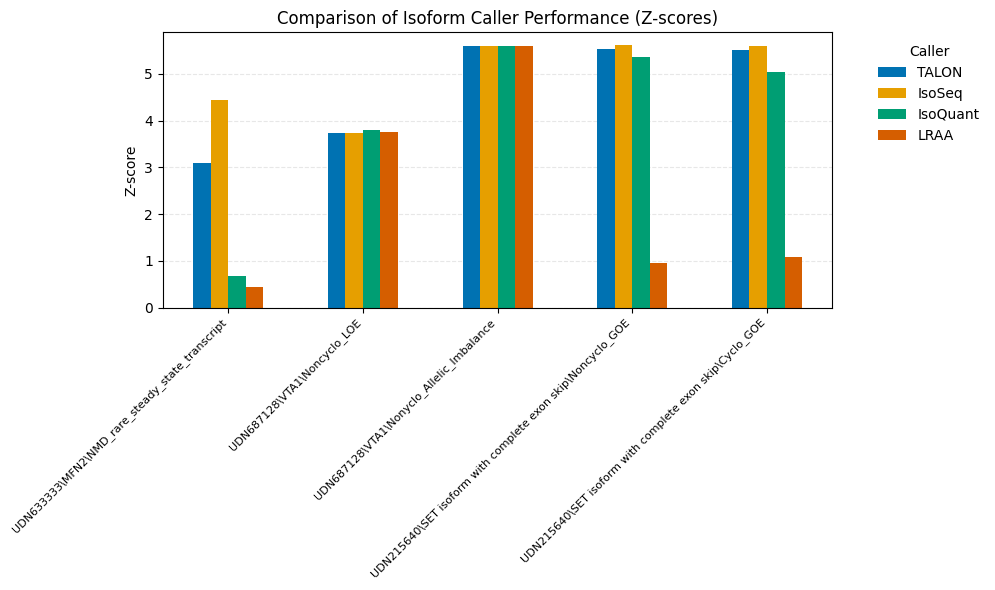

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

##########################################
# Inputs
##########################################

# Define where each caller’s populated CSV lives
CALLER_FILES = {
    "TALON": "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Jupyter/Comparing_isoform_callers/Sample_gene_pairs_populated_iso_allelic_TALON_99.csv",
    "IsoSeq": "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Jupyter/Comparing_isoform_callers/Sample_gene_pairs_populated_iso_allelic_IsoSeq.csv",
    "IsoQuant": "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Jupyter/Comparing_isoform_callers/Sample_gene_pairs_populated_iso_allelic_IsoQuant_no_rankings.csv",
    "LRAA": "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Jupyter/Comparing_isoform_callers/Sample_gene_pairs_populated_iso_allelic_LRAA_no_rankings.csv",
}

# Exact plotting order and corresponding (Sample, Gene, Effect)
TARGETS = [
    ("UDN633333", "MFN2", "Gene NMD rare steady state", "UDN633333\\MFN2\\NMD_rare_steady_state_transcript"),
    ("UDN687128", "VTA1", "Gene Noncyclo LOE", "UDN687128\\VTA1\\Noncyclo_LOE"),
    ("UDN687128", "VTA1", "Gene Noncyclo allelic imbalance", "UDN687128\\VTA1\\Nonyclo_Allelic_Imbalance"),
    ("UDN215640", "SET", "Isoform Noncyclo GOE", "UDN215640\\SET isoform with complete exon skip\\Noncyclo_GOE"),
    ("UDN215640", "SET", "Isoform Cyclo GOE", "UDN215640\\SET isoform with complete exon skip\\Cyclo_GOE"),
]

##########################################
# Helper
##########################################

def extract_z_score(value):
    """
    Safely extract the z-score, which is always the 2nd semicolon-separated value.
    Handles both 'x;y' and 'x;y;z' formats.
    """
    if pd.isna(value) or not isinstance(value, str):
        return None
    parts = value.split(";")
    if len(parts) < 2:
        return None
    try:
        return float(parts[1])
    except ValueError:
        return None

##########################################
# Build z-score table
##########################################

records = []
for caller, csv_path in CALLER_FILES.items():
    df = pd.read_csv(csv_path, dtype=str)

    for sample, gene, effect, label in TARGETS:
        if effect not in df.columns:
            raise KeyError(f"{effect} not found in {caller} CSV.")

        match = df[(df["Sample"] == sample) & (df["Gene"] == gene)]
        if match.empty:
            z = None
        else:
            z = extract_z_score(match.iloc[0][effect])

        records.append({
            "Transcript": label,
            "Caller": caller,
            "Z-score": z
        })

plot_df = pd.DataFrame(records)

# Enforce the desired order
plot_order = [t[-1] for t in TARGETS]
plot_df["Transcript"] = pd.Categorical(plot_df["Transcript"], categories=plot_order, ordered=True)

##########################################
# Plot
##########################################

# Pivot so each caller is a column
plot_pivot = plot_df.pivot(index="Transcript", columns="Caller", values="Z-score").loc[plot_order]

# Color-blind friendly palette (Okabe–Ito)
colors = {
    "TALON": "#0072B2",     # Blue
    "IsoSeq": "#E69F00",    # Orange
    "IsoQuant": "#009E73",  # Green
    "LRAA": "#D55E00"       # Vermilion
}

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(plot_pivot))
width = 0.13
callers = ["TALON", "IsoSeq", "IsoQuant", "LRAA"]

for i, caller in enumerate(callers):
    ax.bar(
        [p + (i - 1.5) * width for p in x],
        plot_pivot[caller],
        width,
        label=caller,
        color=colors[caller]
    )

# Axis labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(plot_pivot.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Z-score")
ax.set_title("Comparison of Isoform Caller Performance (Z-scores)")
ax.legend(title="Caller", frameon=False, bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("caller_performance_ordered.pdf", format="pdf", bbox_inches="tight")
plt.show()
